In [91]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import style


**Define Function**

In [93]:
df=pd.read_csv('/content/drive/MyDrive/WOC/unsupervised_data.csv')
df


,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
0,1,-21.904591,-22.659091,12.805995,-46.631935,-34.347081,-21.989738
1,2,-28.662385,68.757081,31.761821,3.982259,-62.876866,-61.838563
2,3,-62.551204,60.909235,8.112918,24.110050,-64.372336,70.681940
3,4,14.428024,-48.326045,-65.576518,76.027549,69.966852,48.023953
4,5,9.780285,-55.643172,-72.737299,74.180123,67.873327,41.128015
...,...,...,...,...,...,...,...
39995,39996,19.126649,-53.397074,-73.297148,69.415535,75.729247,54.485823
39996,39997,-3.768855,-32.785832,22.813179,-50.865346,-36.385833,-28.710921
39997,39998,-10.519365,51.354702,-45.129637,1.941843,13.162370,-77.770009
39998,39999,47.122315,-47.272906,-47.184628,-52.908391,-29.804291,2.042820


In [94]:
X=df.drop(columns=['ID']).to_numpy()
X

array([[-21.90459052, -22.65909077,  12.80599532, -46.63193454,
        -34.34708058, -21.98973763],
       [-28.6623852 ,  68.7570811 ,  31.76182149,   3.98225896,
        -62.87686557, -61.83856263],
       [-62.55120406,  60.90923463,   8.11291761,  24.1100498 ,
        -64.37233589,  70.68194042],
       ...,
       [-10.5193655 ,  51.35470206, -45.12963703,   1.94184293,
         13.16236957, -77.77000929],
       [ 47.12231456, -47.27290614, -47.18462792, -52.90839123,
        -29.80429118,   2.04282004],
       [-12.18331877,  52.25702955, -42.01543172,  14.20654525,
          0.70609201, -77.29727207]])

In [95]:
def initialize_centroid(X,k):
  row=np.random.choice(X.shape[0],size=k,replace=False)
  return X[row,:]


In [96]:
def dist(x,c):
  m=x.shape[0]
  d=[]
  for i in range(m):
    pd=np.sqrt(np.sum((x[i]-c)**2,axis=1))
    d.append(pd)

  return np.array(d)

In [97]:
def assign(x,c):
  d=dist(x,c)
  a=np.argmin(d,axis=1)
  return a

In [98]:
def update_centroids(a,x):
  centroids=[]

  for k in np.unique(a):
    cluster_points=x[a==k]
    mean_pos=np.mean(cluster_points,axis=0)
    centroids.append(mean_pos)

  return np.array(centroids)

In [99]:
def kmeans(x,k,max_iters=100):
  c=initialize_centroid(x,k)
  c_history=[c]
  for i in range(max_iters):
    a=assign(x,c)
    c_new=update_centroids(a,x)
    c_history.append(c_new)
    if np.allclose(c_history[-1],c_history[-2]):
      print(
          f"Number of iterations taken for the cluster centroids "
          f"to reach the mean centres of {k} clusters: {i}"
      )
      break

    c=c_new

  return c,c_history

In [100]:
def wcss(x,final_c,final_a):
  wcss=0
  for k in np.unique(final_a):
    indices=np.where(final_a==k)[0]
    X=x[indices]
    wcss += np.sum((X-final_c[k])**2)
  return wcss

In [101]:
def elbow(x,max_k):
  w=[]
  k=[]
  for i in range(1,max_k+1):
    final_c,c_history=kmeans(x,i)
    final_a=assign(x,final_c)
    w.append(wcss(x,final_c,final_a))
    k.append(i)
  style.use('default')
  plt.plot(k,w)
  plt.xlabel("k")
  plt.ylabel("wcss")
  plt.title("Elboe Method")
  plt.show()


In [102]:
X.shape

(40000, 6)

**Value of K using Elbow Method**

Number of iterations taken for the cluster centroids to reach the mean centres of 1 clusters: 1
Number of iterations taken for the cluster centroids to reach the mean centres of 2 clusters: 2
Number of iterations taken for the cluster centroids to reach the mean centres of 3 clusters: 20
Number of iterations taken for the cluster centroids to reach the mean centres of 4 clusters: 2
Number of iterations taken for the cluster centroids to reach the mean centres of 5 clusters: 64
Number of iterations taken for the cluster centroids to reach the mean centres of 6 clusters: 16
Number of iterations taken for the cluster centroids to reach the mean centres of 7 clusters: 88


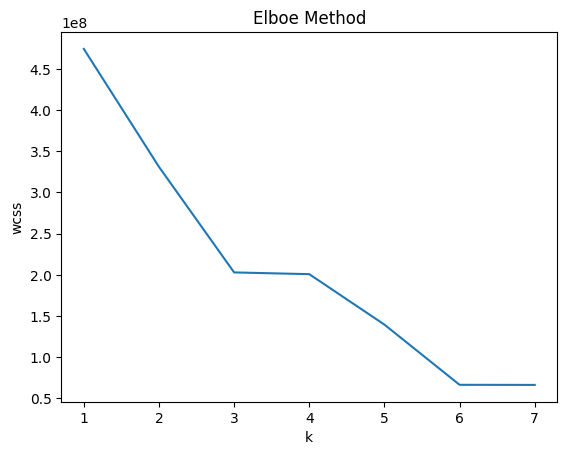

In [103]:
elbow(X,7)

**Runnning K means**

In [ ]:
final_c,c_history=kmeans(X,3)
print(final_c)

In [108]:
final_a=assign(X,final_c)




In [109]:
sample_no = pd.Series(range(1, len(final_a) + 1), name='Sample No.')
final_a_series = pd.Series(final_a, name='Clustr Grp')
result_df = pd.concat([sample_no, final_a_series], axis=1)
result_df

,Sample No.,Clustr Grp
0,1,0
1,2,2
2,3,0
3,4,1
4,5,1
...,...,...
39995,39996,1
39996,39997,0
39997,39998,2
39998,39999,1


In [110]:
result_df.to_csv('KMeanPrediction.csv', index=False)